# SR Interpretability Suite

Expression format: Python arithmetic with variables named `x_0`, `x_1`, ...  
Mixed expressions use sympy `Piecewise` directly for boolean comparisons and conditionals.

In [8]:
import sys
from pathlib import Path

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "sr_analysis.py").exists())
sys.path.insert(0, str(_root))

from sr_analysis import (
    simplify_expression, variable_contributions,
    variable_interactions, complexity_report, behavioral_regimes
)

---
## Reference expression — Example 1 (continuous)

```
Expression : (x_10**3 + (x_14 - x_7))
Variables  : x_7=MutationTaster_score, x_10=MutPred_score, x_14=VEST4_score
             (3 of 24 total; only active variables listed)
```

In [9]:
EXPR = "((x_10**3 * x_7) + (x_14 - x_7) + 1/(x_10 - 0.5))"

# --- shared fixtures ---
VAR_MAP = {
    "x_0":  "pos",
    "x_1":  "end",
    "x_2":  "aa_pos",
    "x_3":  "phyloP17way_primate",
    "x_4":  "phastCons17way_primate",
    "x_5":  "SiPhy_29way_logOdds",
    "x_6":  "GERP++_RS",
    "x_7":  "MutationTaster_score",
    "x_8":  "LRT_score",
    "x_9":  "FATHMM_score",
    "x_10": "MutPred_score",
    "x_11": "SIFT_score",
    "x_12": "MutationAssessor_score",
    "x_13": "PROVEAN_score",
    "x_14": "VEST4_score",
    "x_15": "Polyphen2_HDIV_score",
    "x_16": "Polyphen2_HVAR_score",
    "x_17": "log_AF_popmax",
    "x_18": "is_transition",
    "x_19": "sub_code",
    "x_20": "blosum62",
    "x_21": "delta_hydro",
    "x_22": "delta_volume",
    "x_23": "delta_charge",
}

# scores in [0,1], log_AF in [-8,0], positional ints, conservation scores
VAR_RANGES = {
    "x_0":  (1, 50000),
    "x_1":  (1, 50000),
    "x_2":  (1, 2000),
    "x_3":  (-3.0, 3.0),
    "x_4":  (0.0, 1.0),
    "x_5":  (0.0, 20.0),
    "x_6":  (-10.0, 10.0),
    "x_7":  (0.0, 1.0),
    "x_8":  (0.0, 1.0),
    "x_9":  (-5.0, 5.0),
    "x_10": (0.0, 1.0),
    "x_11": (0.0, 1.0),
    "x_12": (0.0, 5.0),
    "x_13": (-10.0, 5.0),
    "x_14": (0.0, 1.0),
    "x_15": (0.0, 1.0),
    "x_16": (0.0, 1.0),
    "x_17": (-8.0, 0.0),
    "x_18": (0, 1),
    "x_19": (0, 20),
    "x_20": (-4, 11),
    "x_21": (-3.0, 3.0),
    "x_22": (-200.0, 200.0),
    "x_23": (-2, 2),
}

# Test expressions — each stresses different functions
EXPR_BASE     = "((x_10**3 * x_7) + (x_14 - x_7))"           # x_7 dual role, interaction
EXPR_CONST    = "((2.5 * x_10**2) + (2.5 / (x_14 + 2.5)) - x_7)"  # constant recurrence
EXPR_INTERACT = "((x_10 * x_7) / (x_14 + 0.1) + x_10**2 * x_14)"  # multiple interactions
EXPR_REGIME   = "((x_10**3 * x_7) + (x_14 - x_7) + 1/(x_10 - 0.5))"  # singularity at x_10=0.5

---
## Function 1 — `simplify_expression`

Parses the expression with sympy, simplifies it, and reports node count reduction and collapsed constants.

In [10]:
simplified = simplify_expression(EXPR, VAR_MAP)

print(f"Original          : {simplified['original']}")
print(f"Simplified (x_N)  : {simplified['simplified']}")
print(f"Simplified (named): {simplified['simplified_named']}")
print(f"Nodes             : {simplified['nodes_before']} -> {simplified['nodes_after']}")
print(f"Is mixed          : {simplified['is_mixed']}")
print(f"Continuous vars   : {simplified['continuous_vars']}")

Original          : ((x_10**3 * x_7) + (x_14 - x_7) + 1/(x_10 - 0.5))
Simplified (x_N)  : x_10**3*x_7 + x_14 - x_7 + 1/(x_10 - 0.5)
Simplified (named): MutPred_score**3*MutationTaster_score + VEST4_score - MutationTaster_score + 1/(MutPred_score - 0.5)
Nodes             : 15 -> 15
Is mixed          : False
Continuous vars   : ['x_10', 'x_14', 'x_7']


---
## Function 2 — `variable_contributions`

Sweeps each variable over its data range (50 points) while fixing all others at their midpoint.  
Ranks variables by the output range they induce — a proxy for marginal importance.

Variable contribution ranking (by output range):
   x_10  ████████████████████  196.0077
   x_14  (singularity in range)
    x_7  (singularity in range)


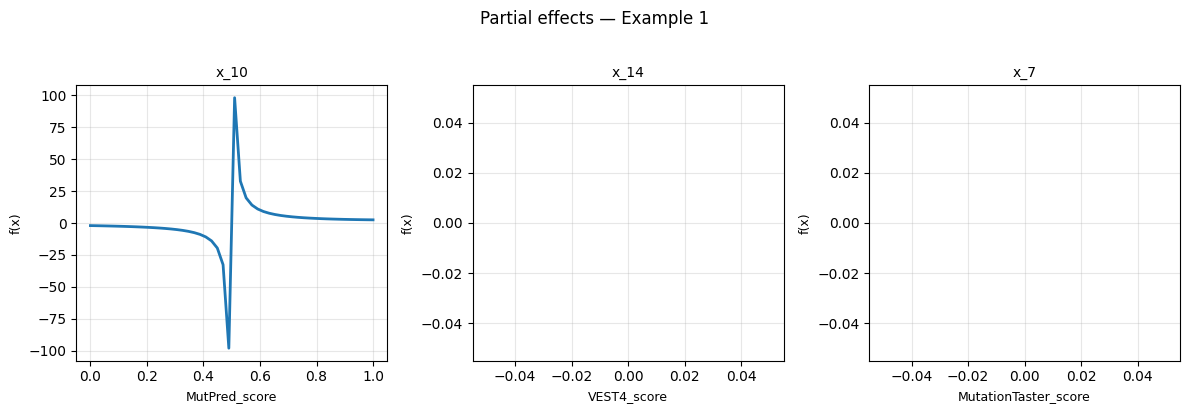

In [11]:
from sympy import symbols
import matplotlib.pyplot as plt
import numpy as np

x_7, x_10, x_14 = symbols("x_7 x_10 x_14")

result = variable_contributions(
    simplified["expr"],
    {x_10: (0, 1), x_14: (0, 1), x_7: (0, 1)}
)

# print rankings
finite_ranges = [r for _, r in result["rankings"] if np.isfinite(r)]
max_rng = max(finite_ranges) if finite_ranges else 1.0
print("Variable contribution ranking (by output range):")
for sym, rng in result["rankings"]:
    if np.isfinite(rng):
        bar = "█" * int(rng / max_rng * 20)
        print(f"  {str(sym):>5s}  {bar:<20s}  {rng:.4f}")
    else:
        print(f"  {str(sym):>5s}  (singularity in range)")

# plot partial effect curves in ranking order (skip non-finite curves)
fig, axes = plt.subplots(1, len(result["rankings"]), figsize=(12, 4), sharey=False)
for ax, (sym, _) in zip(axes, result["rankings"]):
    x_vals, y_vals = result["partial_effects"][sym]
    label = VAR_MAP.get(str(sym), str(sym))
    mask = np.isfinite(y_vals)
    ax.plot(x_vals[mask], y_vals[mask], linewidth=2)
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel("f(x)", fontsize=9)
    ax.set_title(f"{sym}", fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle("Partial effects — Example 1", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

---
## Function 3 — `variable_interactions`

Computes the mixed partial derivative d²f/dxᵢ dxⱼ for every variable pair.  
A nonzero result means the two variables interact: one modifies the marginal effect of the other.  
Variables with no nonzero mixed partials are structurally independent.

In [12]:
result = variable_interactions(simplified["expr"])

print("Interacting pairs (d²f/dxi dxj ≠ 0):")
if result["interacting_pairs"]:
    for xi, xj, d2f in result["interacting_pairs"]:
        print(f"  ({xi}, {xj})  mixed partial = {d2f}")
else:
    print("  none — all variables contribute independently")

print()
print("Independent variables:")
for v in result["independent_vars"]:
    print(f"  {v}  ({VAR_MAP.get(str(v), str(v))})") 

Interacting pairs (d²f/dxi dxj ≠ 0):
  (x_10, x_7)  mixed partial = 3*x_10**2

Independent variables:
  x_14  (VEST4_score)


---
## Function 4 — `complexity_report`

Estimates each subtree's contribution to output variance using 200 random samples.  
Subtrees are replaced by their sample mean; the resulting variance drop measures contribution.  
Subtrees contributing less than 5% are flagged as pruning candidates.

In [13]:
result = complexity_report(
    simplified["expr"],
    {x_10: (0, 1), x_14: (0, 1), x_7: (0, 1)}
)

print(f"Node count: {result['node_count']}")
print()

print(f"  {'Subtree':<30s}  {'Contribution %':>14s}")
print(f"  {'-'*30}  {'-'*14}")
for s in result["subtrees"]:
    flag = "  <- prune?" if s["contribution_pct"] < 5.0 else ""
    print(f"  {s['expr']:<30s}  {s['contribution_pct']:>13.1f}%{flag}")
print()

# if one term dominates, show residual contributions with it fixed
if result["dominant_term"]:
    print(f"Dominant term: {result['dominant_term']} — residual contributions (dominant fixed at mean):")
    print(f"  {'Subtree':<30s}  {'Contribution %':>14s}")
    print(f"  {'-'*30}  {'-'*14}")
    for s in result["residual_subtrees"]:
        flag = "  <- prune?" if s["contribution_pct"] < 5.0 else ""
        print(f"  {s['expr']:<30s}  {s['contribution_pct']:>13.1f}%{flag}")
    print()

if result["pruning_candidates"]:
    print("Pruning candidates (< 5% contribution):")
    for s in result["pruning_candidates"]:
        print(f"  {s}")
else:
    print("No pruning candidates — all subtrees contribute >= 5%")

Node count: 15

  Subtree                         Contribution %
  ------------------------------  --------------
  1/(x_10 - 0.5)                          100.0%
  x_10**3*x_7                               0.0%  <- prune?
  -x_7                                     -0.0%  <- prune?
  x_14                                     -0.1%  <- prune?



KeyError: 'dominant_term'

---
## Function 5 — 

For each variable: finds critical points (f'=0), inflection points (f''=0),  
singularities (denominator zeros), and reports whether the variable is monotonic  
over its data range (all others fixed at midpoint).

In [14]:
result = behavioral_regimes(
    simplified["expr"],
    {x_10: (0, 1), x_14: (0, 1), x_7: (0, 1)}
)

for var, info in result["variables"].items():
    label = VAR_MAP.get(str(var), str(var))
    print(f"{var}  ({label})")
    print(f"  Critical points   : {info['critical_points'] or 'none'}")
    print(f"  Inflection points : {info['inflection_points'] or 'none'}")
    print(f"  Singularities     : {info['singularities'] or 'none'}")
    print(f"  Monotonic         : {info['monotonic']}")
    print()

x_10  (MutPred_score)
  Critical points   : none
  Inflection points : none
  Singularities     : [0.5]
  Monotonic         : False

x_14  (VEST4_score)
  Critical points   : none
  Inflection points : none
  Singularities     : none
  Monotonic         : True

x_7  (MutationTaster_score)
  Critical points   : none
  Inflection points : none
  Singularities     : none
  Monotonic         : True

